In [ ]:
import pandas as pd
df=pd.read_csv('/content/sample_data/internet_service_churn_features (1).csv')

In [ ]:
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,Age Group,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,is_contract_missing,remaining_contract_group,bundle_count,cost_per_gb,failures_per_year,inferred_discount
0,15,1,0.0,Old User,11.95,25,0.14,0,8.4,2.3,0,0,0,No Contract / Short Term,Tv Or Movies,2.136752,0.000000,0
1,18,0,0.0,Old User,8.22,0,0.00,0,0.0,0.0,0,1,1,No Contract / Short Term,Internet Only,0.000000,0.000000,22
2,23,1,0.0,Old User,8.91,16,0.00,0,13.7,0.9,0,1,0,No Contract / Short Term,Tv Or Movies,1.025641,0.000000,4
3,27,0,0.0,Old User,6.87,21,0.00,1,0.0,0.0,0,1,1,No Contract / Short Term,Internet Only,21.000000,0.143472,1
4,34,0,1.0,Old User,6.39,0,0.00,0,0.0,0.0,0,1,1,No Contract / Short Term,Internet Only,0.000000,0.000000,22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72273 non-null  float64
 3   Age Group                    72274 non-null  object 
 4   subscription_age             72274 non-null  float64
 5   bill_avg                     72274 non-null  int64  
 6   remaining_contract           72274 non-null  float64
 7   service_failure_count        72274 non-null  int64  
 8   download_avg                 72274 non-null  float64
 9   upload_avg                   72274 non-null  float64
 10  download_over_limit          72274 non-null  int64  
 11  churn                        72274 non-null  int64  
 12  is_contract_missing          72274 non-null  int64  
 13  remaining_contra

In [ ]:
df.describe(include='all')

,id,is_tv_subscriber,is_movie_package_subscriber,Age Group,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,is_contract_missing,remaining_contract_group,bundle_count,cost_per_gb,failures_per_year,inferred_discount
count,7.227400e+04,72274.000000,72273.000000,72274,72274.000000,72274.000000,72274.000000,72274.000000,72274.000000,72274.000000,72274.000000,72274.000000,72274.000000,72274,72274,72274.000000,72274.000000,72274.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN
top,NaN,NaN,NaN,New User,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Contract / Short Term,Tv Or Movies,NaN,NaN,NaN
freq,NaN,NaN,NaN,37290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54397,34741,NaN,NaN,NaN
mean,8.463182e+05,0.815259,0.334634,NaN,2.450051,18.942483,0.502319,0.274234,43.459595,4.169977,0.207613,0.554141,0.298475,NaN,NaN,2.943547,0.230302,4.225586
std,4.891022e+05,0.388090,0.471866,NaN,2.034990,13.215386,0.669524,0.816621,63.317706,9.797685,0.997123,0.497064,0.457592,NaN,NaN,6.954892,1.012917,5.948466
min,1.500000e+01,0.000000,0.000000,NaN,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,NaN,0.930000,13.000000,0.000000,0.000000,6.400000,0.500000,0.000000,0.000000,0.000000,NaN,NaN,0.220588,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,NaN,1.980000,19.000000,0.000000,0.000000,27.500000,2.100000,0.000000,1.000000,0.000000,NaN,NaN,0.474630,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,NaN,3.300000,22.000000,1.040000,0.000000,60.200000,4.800000,0.000000,1.000000,1.000000,NaN,NaN,1.383648,0.000000,7.000000


**Replacing Null Values**

In [ ]:
# 1. Address 'reamining_contract' (Notice the typo in the raw column name)
# Capture the predictive signal with a missing indicator flag
df['is_contract_missing'] = df['remaining_contract'].isnull().astype(int)

# Fill the nulls with 0 (representing no remaining contract time)
df['remaining'] = df['remaining_contract'].fillna(0)




# 2. Address 'download_avg' and 'upload_avg'
# Fill with 0 since these represent brand new accounts with no usage history yet
df['download_avg'] = df['download_avg'].fillna(0)
df['upload_avg'] = df['upload_avg'].fillna(0)


# Verify all nulls are resolved (Using the corrected 'remaining_contract' name now)
print(df[['remaining_contract', 'download_avg', 'upload_avg']].isnull().sum())

remaining_contract    0
download_avg          0
upload_avg            0
dtype: int64


In [ ]:
df.isnull().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,1
Age Group,0
subscription_age,0
bill_avg,0
remaining_contract,0
service_failure_count,0
download_avg,0
upload_avg,0


**Snake Case format Column**

In [ ]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ","_")

In [ ]:
df.columns

Index(['id', 'is_tv_subscriber', 'is_movie_package_subscriber', 'age_group',
       'subscription_age', 'bill_avg', 'remaining_contract',
       'service_failure_count', 'download_avg', 'upload_avg',
       'download_over_limit', 'churn', 'is_contract_missing',
       'remaining_contract_group', 'bundle_count', 'cost_per_gb',
       'failures_per_year', 'inferred_discount', 'remaining'],
      dtype='object')

**Grouping major column**

In [ ]:
labels=['No Contract / Short Term','Long Term']
df['remaining_contract_group']=pd.qcut(df['remaining_contract'],q=4,labels=labels, duplicates='drop')

In [ ]:
df[['remaining_contract','remaining_contract_group']].head(10)

,remaining_contract,remaining_contract_group
0,0.14,No Contract / Short Term
1,0.00,No Contract / Short Term
2,0.00,No Contract / Short Term
3,0.00,No Contract / Short Term
4,0.00,No Contract / Short Term
5,1.38,Long Term
6,0.00,No Contract / Short Term
7,0.00,No Contract / Short Term
8,0.00,No Contract / Short Term
9,0.00,No Contract / Short Term


**Creating New Column**

In [ ]:
# =========================================================================
# FEATURE 1: Product Bundle Score (bundle_count)
# Combines TV and movie choices into a single measure of customer 'stickiness'
# =========================================================================
df['bundle_count'] = df['is_tv_subscriber'] + df['is_movie_package_subscriber']


# =========================================================================
# FEATURE 2: Price Sensitivity Metric (cost_per_gb)
# Measures perceived financial value (Average Bill / Total Data Transmitted)
# Note: Adding 1 to the denominator avoids division-by-zero errors
# =========================================================================
df['cost_per_gb'] = df['bill_avg'] / (df['download_avg'] + df['upload_avg'] + 1)


# =========================================================================
# FEATURE 3: Service Friction Rate (failures_per_year)
# Normalizes service disruptions relative to the customer's total lifespan
# Note: Adding 0.1 prevents division-by-zero errors for brand-new accounts
# =========================================================================
df['failures_per_year'] = df['service_failure_count'] / (df['subscription_age'] + 0.1)


# 3. Clean up the contract column name typo for a polished schema
df = df.rename(columns={'reamining_contract': 'remaining_contract'})

# =========================================================================
# FEATURE 4: Inferred Bundle Discount (inferred_discount)
# Calculates how much less a user pays compared to the standard median rate
# for their specific combination of TV/Movie subscriptions.
# =========================================================================
# Step A: Find the standard median price for active paying users (bill_avg > 0) in each tier
paying_users = df[df['bill_avg'] > 0]
tier_baselines = paying_users.groupby(['is_tv_subscriber', 'is_movie_package_subscriber'])['bill_avg'].median()

# Step B: Merge the baseline prices back into the main dataframe
df = df.merge(
    tier_baselines.rename('tier_median_bill'),
    on=['is_tv_subscriber', 'is_movie_package_subscriber'],
    how='left'
)

# Step C: Calculate the discount amount
# Users paying more than the baseline get a 0 (via .clip) rather than a negative discount
df['inferred_discount'] = (df['tier_median_bill'] - df['bill_avg']).clip(lower=0)

# Drop the temporary baseline helper column
df = df.drop(columns=['tier_median_bill'])

# 5. Save the newly engineered dataset to a new file
df.to_csv('internet_service_churn_features.csv', index=False)

print("Features successfully added! Saved to 'internet_service_churn_features.csv'")

Features successfully added! Saved to 'internet_service_churn_features.csv'


In [ ]:
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,age_group,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,is_contract_missing,remaining_contract_group,bundle_count,cost_per_gb,failures_per_year,inferred_discount,remaining
0,15,1,0.0,Old User,11.95,25,0.14,0,8.4,2.3,0,0,0,No Contract / Short Term,1.0,2.136752,0.000000,0.0,0.14
1,18,0,0.0,Old User,8.22,0,0.00,0,0.0,0.0,0,1,0,No Contract / Short Term,0.0,0.000000,0.000000,21.0,0.00
2,23,1,0.0,Old User,8.91,16,0.00,0,13.7,0.9,0,1,0,No Contract / Short Term,1.0,1.025641,0.000000,4.0,0.00
3,27,0,0.0,Old User,6.87,21,0.00,1,0.0,0.0,0,1,0,No Contract / Short Term,0.0,21.000000,0.143472,0.0,0.00
4,34,0,1.0,Old User,6.39,0,0.00,0,0.0,0.0,0,1,0,No Contract / Short Term,1.0,0.000000,0.000000,22.0,0.00


**Explainatory Data Analysis**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

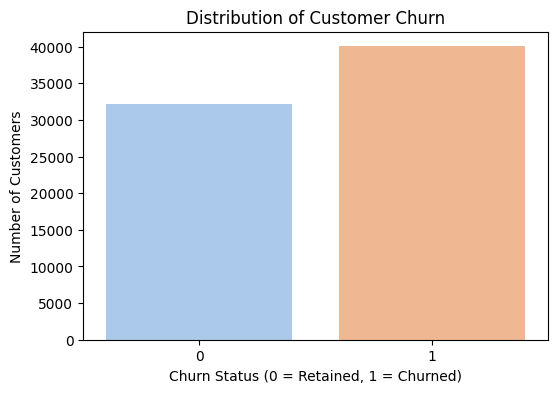

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn", hue="churn", palette="pastel", legend=False)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

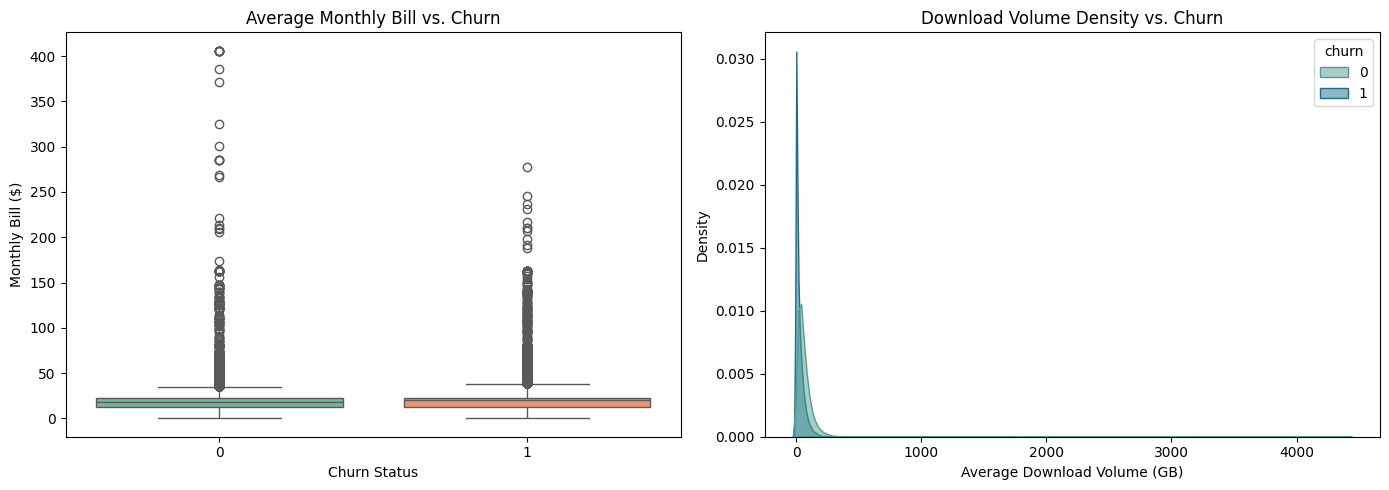

In [ ]:
# Create side-by-side plots for Billing and Download Volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Average Bill Distribution by Churn Status
sns.boxplot(ax=axes[0], data=df, x="churn", y="bill_avg", palette="Set2", hue="churn", legend=False)
axes[0].set_title("Average Monthly Bill vs. Churn")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Monthly Bill ($)")

# Plot B: Average Download Volume Distribution by Churn Status
sns.kdeplot(ax=axes[1], data=df, x="download_avg", hue="churn", fill=True, common_norm=False, palette="crest", alpha=0.5)
axes[1].set_title("Download Volume Density vs. Churn")
axes[1].set_xlabel("Average Download Volume (GB)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

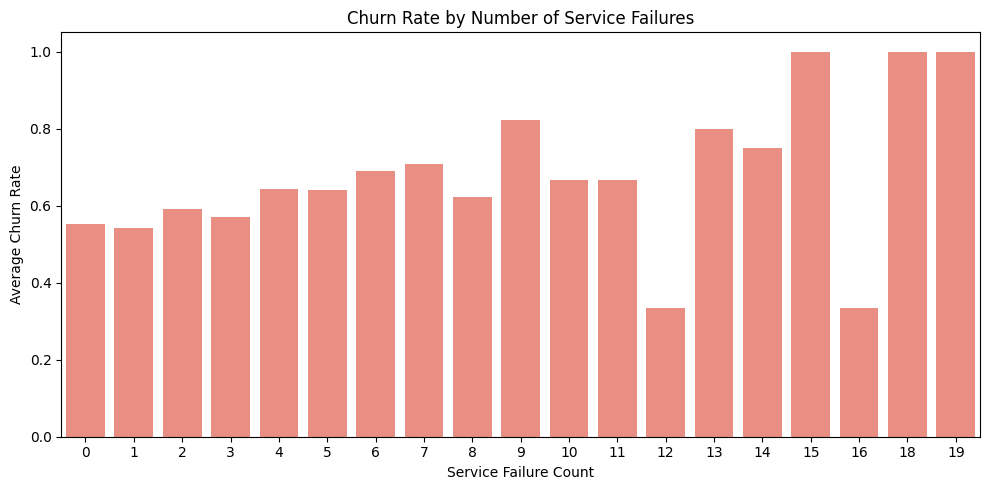

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="service_failure_count", y="churn", errorbar=None, color="salmon")
plt.title("Churn Rate by Number of Service Failures")
plt.xlabel("Service Failure Count")
plt.ylabel("Average Churn Rate")
plt.tight_layout()
plt.show()

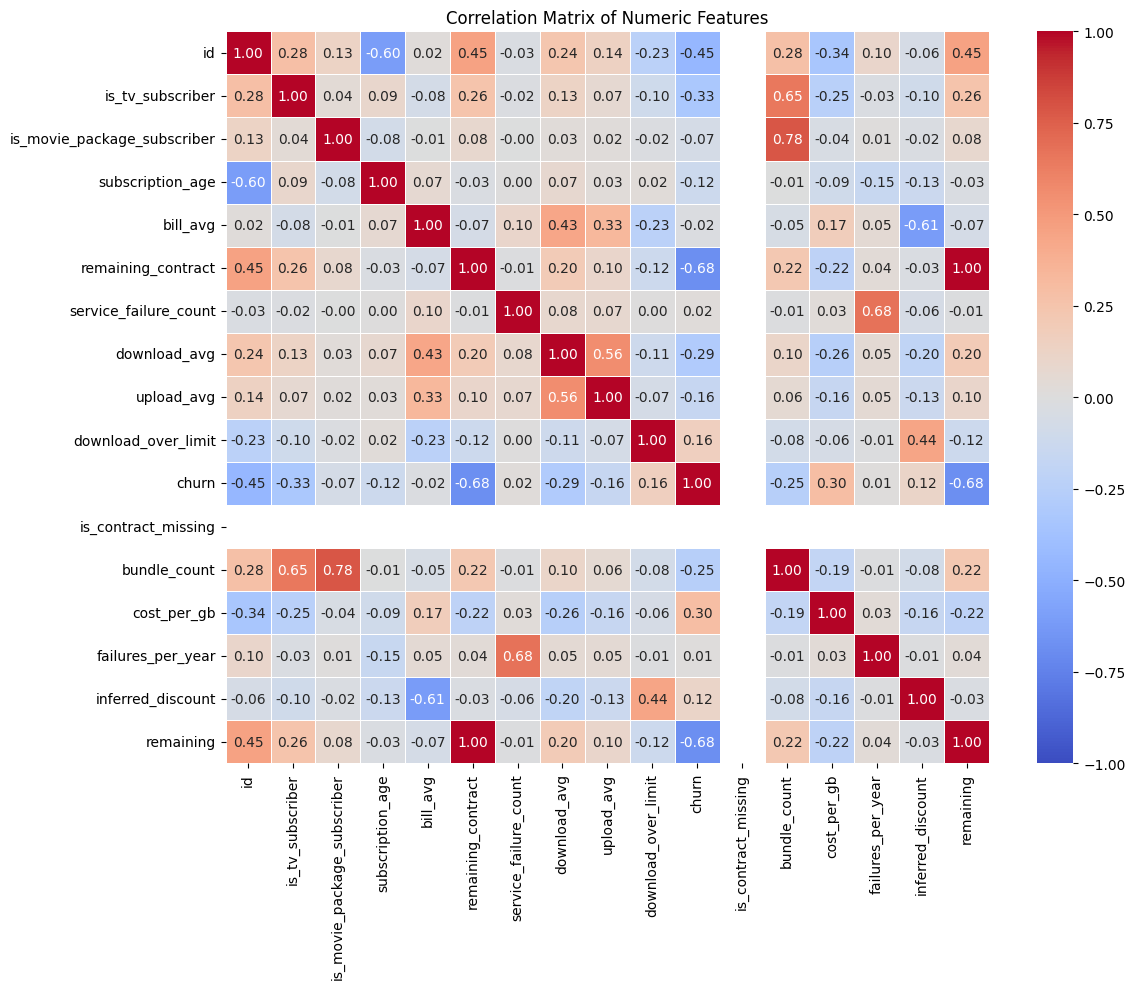

In [ ]:
plt.figure(figsize=(12, 10))

# Isolate numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Generate heatmap matrix
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

**Using XG Boost**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from xgboost import XGBClassifier

In [ ]:

X = df.drop(columns=["churn", "id"], errors="ignore")  # Drops target and unique IDs
y = df["churn"].astype(int)  # Ensures target is a binary integer

# ==========================================
# 1. SPLIT DATA INTO TRAIN & TEST SETS
# ==========================================
# Now X and y exist, so this line will run smoothly!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# If you have categorical/string columns, ensure their type is set to 'category'
categorical_cols = X_train.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

# ==========================================
# 2. CREATE AND INITIALIZE THE XGBOOST MODEL
# ==========================================
model = XGBClassifier(
    n_estimators=150,  # Number of gradient boosted trees
    learning_rate=0.08,  # Step size shrinkage to prevent overfitting
    max_depth=5,  # Maximum depth of a tree
    eval_metric="logloss",  # Evaluation metric for binary classification
    enable_categorical=True,  # Allows XGBoost to handle 'category' columns natively
    random_state=42,  # Ensures reproducible results
)

# ==========================================
# 3. TRAIN / FIT THE MODEL
# ==========================================
model.fit(X_train, y_train)

# ==========================================
# 4. MAKE PREDICTIONS (IMPLEMENTATION)
# ==========================================
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ==========================================
# 5. QUICK EVALUATION
# ==========================================
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9382
ROC-AUC Score: 0.9779

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6445
           1       0.96      0.93      0.94      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# Step 1: Quick numeric conversion for Scikit-Learn compatibility
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
# Ensure both sets have matching column layouts after encoding
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Step 2: Initialize and implement the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores for faster training
)

rf_model.fit(X_train_encoded, y_train)
y_pred_rf = rf_model.predict(X_test_encoded)

print("--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6445
           1       0.95      0.93      0.94      8010

    accuracy                           0.94     14455
   macro avg       0.93      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



**CatBoost (Categorical Boosting)**

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# Install catboost if not already installed

# Identify indexes of string/object columns for CatBoost to monitor
cat_features_indices = [X_train.columns.get_loc(col) for col in X_train.select_dtypes(include=['object', 'category']).columns]

# Initialize the model
cat_model = CatBoostClassifier(
    iterations=150,
    learning_rate=0.08,
    depth=5,
    random_state=42,
    verbose=0 # Keeps the output clean during training
)

# Train and predict (passing the column indices directly)
cat_model.fit(X_train, y_train, cat_features=cat_features_indices)
y_pred_cat = cat_model.predict(X_test)

print("--- CatBoost Performance ---")
print(classification_report(y_test, y_pred_cat))

--- CatBoost Performance ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6445
           1       0.95      0.93      0.94      8010

    accuracy                           0.94     14455
   macro avg       0.93      0.94      0.93     14455
weighted avg       0.94      0.94      0.94     14455



**SHAP**

In [ ]:
pip install shap

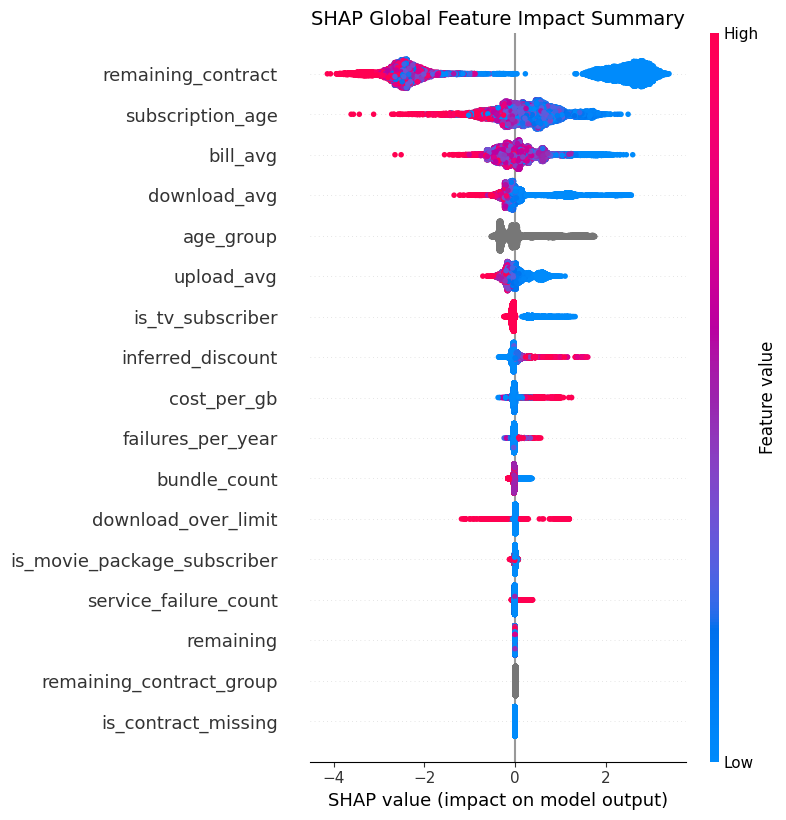

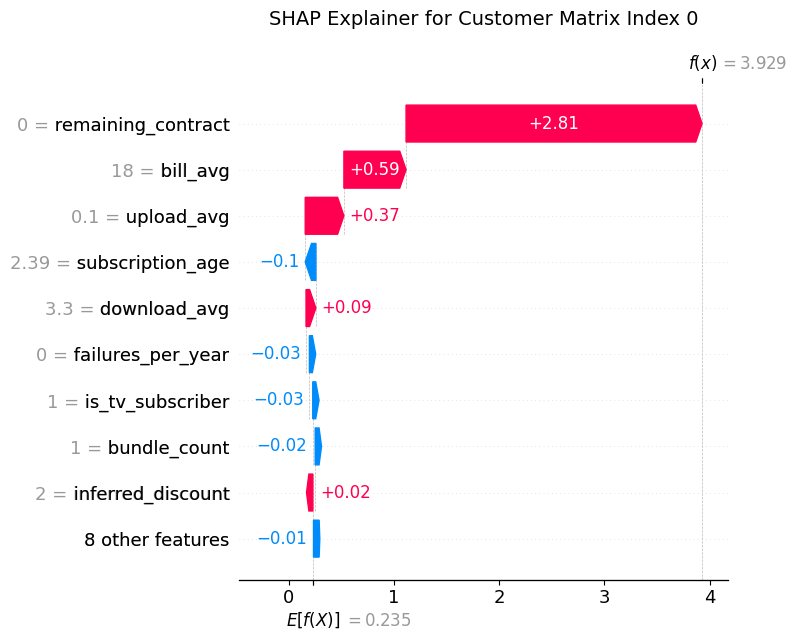

In [ ]:
import shap
import matplotlib.pyplot as plt

# ==========================================
# 1. INITIALIZE THE SHAP EXPLAINER
# ==========================================
# TreeExplainer is heavily optimized for tree models like XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for your test dataset
# (We pass the underlying matrix data so SHAP can compute tree paths)
shap_values = explainer(X_test)

# ==========================================
# 2. GLOBAL EXPLANATION: SUMMARY PLOT
# ==========================================
# This plot combines feature importance with feature effects.
# Red means the feature value was high; Blue means it was low.
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Impact Summary", fontsize=14)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 3. LOCAL EXPLANATION: INDIVIDUAL CUSTOMER
# ==========================================
# Let's see exactly why a single specific customer (e.g., index 0) is predicted to churn or stay
customer_index = 0

plt.figure(figsize=(12, 4))
# Waterfall plot displays the push and pull forces of each feature for this one user
shap.plots.waterfall(shap_values[customer_index], show=False)
plt.title(f"SHAP Explainer for Customer Matrix Index {customer_index}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**SQl**

In [ ]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. DATABASE LAYER: SQLITE
# ==========================================
# This single line automatically creates a real SQL database file called 'churn.db'
conn = sqlite3.connect("churn.db")

# Load your local CSV data and write it directly into an SQL table named 'customer'
df_csv = pd.read_csv("/content/internet_service_churn_features.csv")
df_csv.to_sql("customer", conn, if_exists="replace", index=False)

# This is the exact SQL code you will present to your BRAC Uni defense board:
query = """
SELECT
    bill_avg,
    download_avg,
    upload_avg,
    service_failure_count,
    subscription_age,
    "Age Group",
    remaining_contract_group,
    churn
FROM customer
WHERE churn IS NOT NULL;
"""
df = pd.read_sql(query, conn)
conn.close() # Safely close connection

# ==========================================
# 2. MACHINE LEARNING LAYER: XGBOOST
# ==========================================
X = df.drop(columns=["churn"])
y = df["churn"].astype(int)

# Handle text/categorical columns for XGBoost
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    eval_metric="logloss",
    enable_categorical=True,
    random_state=42
)
model.fit(X_train, y_train)

# Quick verification
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8555


In [ ]:
import os
import sqlite3
import pandas as pd

# ==========================================
# CONFIGURATION
# ==========================================
csv_filename = "/content/internet_service_churn_features.csv"
db_filename = "churn.db"
table_name = "customer"

# Check if the CSV file exists in your directory before proceeding
if not os.path.exists(csv_filename):
    raise FileNotFoundError(
        f"Could not find '{csv_filename}'. Make sure it is in the same folder as this script!"
    )

print("Initializing database build...")

# ==========================================
# 1. CREATE & CONNECT TO THE DATABASE
# ==========================================
# This line instantly creates 'churn.db' if it doesn't exist already
conn = sqlite3.connect(db_filename)
cursor = conn.cursor()

# ==========================================
# 2. READ CSV AND STREAM INTO SQLITE
# ==========================================
print(f"Reading '{csv_filename}' into memory...")
df = pd.read_csv(csv_filename)

print(f"Writing {len(df):,} records into SQL table '{table_name}'...")
# if_exists='replace' ensures that if you re-run this code, it refreshes cleanly
df.to_sql(table_name, conn, if_exists="replace", index=False)

# ==========================================
# 3. VERIFY THE BUILD SUCCESS
# ==========================================
# Let's run a quick query to prove the database is functional
print("\n--- Verifying Database Build ---")
try:
    # Query checking the row count
    cursor.execute(f"SELECT COUNT(*) FROM {table_name};")
    total_rows = cursor.fetchone()[0]
    print(f"Success! Total rows stored in SQL table: {total_rows:,}")

    # Query grabbing column headers to verify schema integrity
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = [col[1] for col in cursor.fetchall()]
    print(f"Database Schema Columns successfully mapped: {len(columns)}")
    print(f"Database file saved locally as: '{os.path.abspath(db_filename)}'")

except sqlite3.OperationalError as e:
    print(f"Database Build Failed: {e}")

finally:
    # Always close database connections when finished
    conn.close()
    print("\nDatabase connection safely closed.")

Initializing database build...
Reading '/content/internet_service_churn_features.csv' into memory...
Writing 72,274 records into SQL table 'customer'...

--- Verifying Database Build ---
Success! Total rows stored in SQL table: 72,274
Database Schema Columns successfully mapped: 19
Database file saved locally as: '/content/churn.db'

Database connection safely closed.


In [47]:
table="""CREATE TABLE COST
id  INTEGER PRIMARY KEY AUTO INCREMENT
REMAINING_CONTRACT VARCHAR(255) NOT NULL
IS_TV_SUBSCRIBER INTEGERR(16) NOT NULL"""

conn.close()